# NEO Classification — ROC Curve Analysis

**Goal:** Use the velocity-space probability maps to classify objects as NEOs.

**Classification rule:** call an object a NEO if $P_\text{NEO} > x$, where $x \in [0,1]$ is a tunable threshold.

**Key quantities:**

| Symbol | Meaning |
|---|---|
| $N^\text{NEO}_\text{cand}(x)$ | True NEOs passing the cut — **true positives** |
| $N^\text{MBA}_\text{cand}(x)$ | MBAs passing the cut — **false positives** |
| $N^\text{NEO}_\text{true}$ | Total real NEOs in the visible sample |

$$\text{Completeness}(x) = \frac{N^\text{NEO}_\text{cand}(x)}{N^\text{NEO}_\text{true}}$$

$$\text{Contamination}(x) = 1 - \text{Purity}(x) = \frac{N^\text{non-NEO}_\text{cand}(x)}{N^\text{NEO}_\text{cand}(x) + N^\text{non-NEO}_\text{cand}(x)}$$

**ROC curve:** sweep $x$ from 0 → 1 and plot completeness (x-axis) vs contamination (y-axis), both in %.

In [7]:
%reload_ext autoreload
%autoreload 2
%aimport -jax
%aimport -jaxlib
%aimport -adam_core

## 1. What is in `s3m_scored_2025-03-21.parquet`?

This file was produced by scoring all four S3M populations (NEO, MBA, TNO, Trojan) against the velocity-space probability maps.  
Only objects that fall inside the sky patch (ecliptic lon=180°, lat=0°, radius=30°) **and** have a valid apparent magnitude are retained.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("s3m_scored_2025-03-21.parquet")

print(f"Total rows: {len(df):,}")
print(f"\nTrue population counts:")
print(df["true_population"].value_counts().to_string())
print(f"\nFirst 5 rows:")
df.head()

Total rows: 1,454,634

True population counts:
true_population
MBA        1410105
Trojans      23605
NEO          13497
TNO           7427

First 5 rows:


,true_population,vlam,vbeta,mag_app,mag_bin_label,H,P_NEO,P_MBA,P_TNO,P_Trojans
0,NEO,-0.224582,0.020553,18.110710,18_20,11.452,0.000399,0.999598,3.517355e-07,0.000003
1,NEO,-0.346591,0.053089,16.340715,16_18,12.430,0.701057,0.296294,0.000000e+00,0.002649
2,NEO,-0.385974,-0.013405,17.992193,16_18,13.901,0.830255,0.167089,0.000000e+00,0.002656
3,NEO,-0.258691,0.032913,18.760917,18_20,14.092,0.000599,0.999400,2.122834e-07,0.000001
4,NEO,-0.274626,-0.008760,20.302876,mag20,15.092,0.008860,0.991136,1.010433e-06,0.000004


### Column descriptions

| Column | Description |
|---|---|
| `true_population` | Ground truth: which S3M population this object came from (NEO / MBA / TNO / Trojans) |
| `vlam` | Ecliptic longitude rate $\dot{\lambda}$ (deg/day) — x-axis of the velocity map |
| `vbeta` | Ecliptic latitude rate $\dot{\beta}$ (deg/day) — y-axis of the velocity map |
| `mag_app` | Apparent magnitude at the observation epoch |
| `mag_bin_label` | Which magnitude bin was used to look up the probability map |
| `H` | Absolute magnitude |
| `P_NEO` | **Probability this object is a NEO** — the classifier score |
| `P_MBA` | Probability this object is an MBA |
| `P_TNO` | Probability this object is a TNO |
| `P_Trojans` | Probability this object is a Trojan |

Probabilities are **not** constrained to sum to 1 — each is an independent Bayesian posterior from the kNN density maps.

## 2. ROC Curve Calculation

We sweep the threshold $x$ from 0 to 1.  
At each $x$ we count how many true NEOs and how many impostors pass the cut $P_\text{NEO} > x$.

In [16]:
#  Ground truth masks 
is_neo = df["true_population"] == "NEO"
p_neo  = df["P_NEO"].to_numpy()

N_true_NEO = is_neo.sum()         # total real NEOs visible in the sky patch
print(f"N_true_NEO = {N_true_NEO:,}  (all real NEOs in the sample)")
print(f"N_non_NEO  = {(~is_neo).sum():,}  (MBA + TNO + Trojans combined)")

#  Sweep thresholds 
thresholds = np.linspace(0, 1, 1001)

N_cand_NEO = np.array([(p_neo[is_neo]   > x).sum() for x in thresholds])   # true positives
N_cand_nonNEO = np.array([(p_neo[~is_neo] > x).sum() for x in thresholds]) # false positives
N_cand_total = N_cand_NEO + N_cand_nonNEO

#  Key metrics (in %) 
completeness  = 100.0 * N_cand_NEO / N_true_NEO
# contamination = fraction of candidates that are NOT true NEOs
contamination = 100.0 * N_cand_nonNEO / np.maximum(N_cand_total, 1)

# Sanity check at x=0 (accept everything) 
i0 = 0   # threshold = 0.0
print(f"\nAt x=0 (accept everything):")
print(f"  Completeness  = {completeness[i0]:.1f}%  (should be ~100%)")
print(f"  Contamination = {contamination[i0]:.1f}%")

# Sanity check at x=1 (accept nothing) 
i1 = -1  # threshold = 1.0
print(f"\nAt x=1 (accept nothing):")
print(f"  Completeness  = {completeness[i1]:.1f}%  (should be ~0%)")
print(f"  N candidates  = {N_cand_total[i1]}")

N_true_NEO = 13,497  (all real NEOs in the sample)
N_non_NEO  = 1,441,137  (MBA + TNO + Trojans combined)

At x=0 (accept everything):
  Completeness  = 16.5%  (should be ~100%)
  Contamination = 99.8%

At x=1 (accept nothing):
  Completeness  = 0.0%  (should be ~0%)
  N candidates  = 0


## 3. ROC Curve Plot

**x-axis:** Completeness — how many real NEOs we recover  
**y-axis:** Contamination — fraction of our candidate list that are impostors  

**Ideal detector:** bottom-right corner (100% completeness, 0% contamination)  
**Useless detector:** top-left corner (the diagonal from top-right to bottom-left)

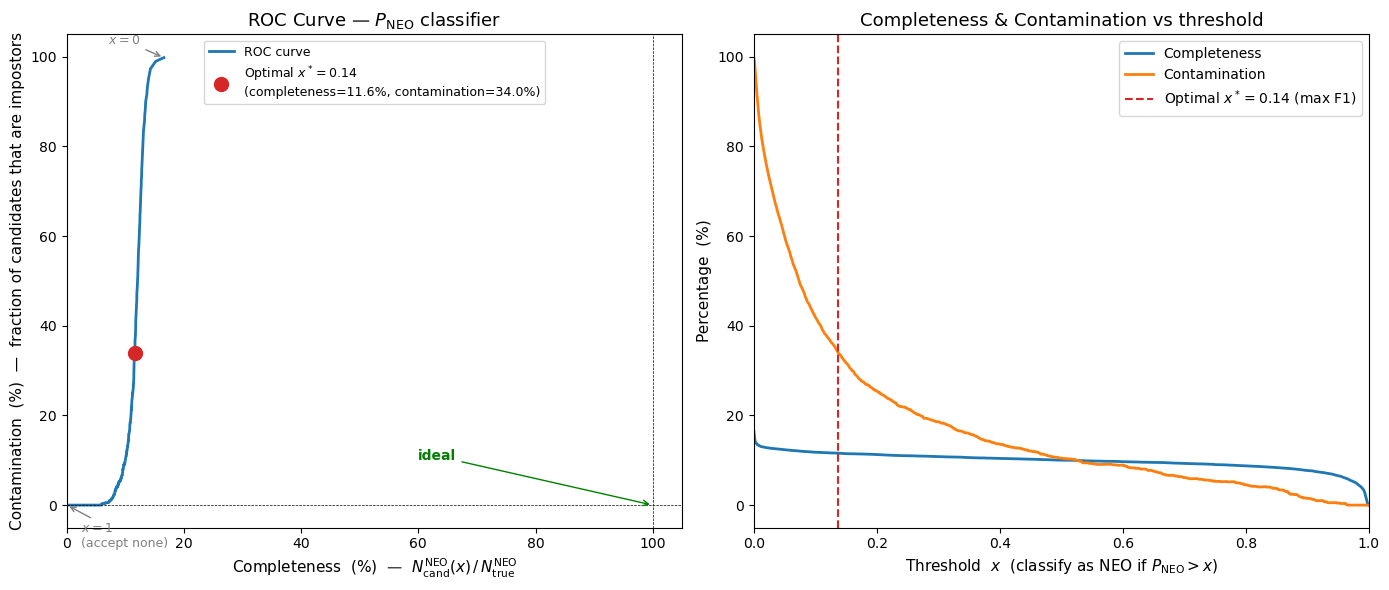

Optimal threshold  x* = 0.137  (maximises F1-score)
  N_cand_NEO    = 1,565   (true NEOs recovered)
  N_cand_nonNEO = 805  (impostors passing cut)
  Completeness  = 11.6%
  Contamination = 34.0%
  Purity        = 66.0%


In [14]:
# Optimal threshold: maximise F1 
purity = 100.0 - contamination                          # in %
# F1 in % units
f1 = 2 * (purity * completeness) / np.maximum(purity + completeness, 1e-9)
i_star = np.argmax(f1)
x_star = thresholds[i_star]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: ROC curve (completeness vs contamination) 
ax = axes[0]
ax.plot(completeness, contamination, lw=2, color="tab:blue", label="ROC curve")

# Mark the optimal threshold
ax.scatter(
    [completeness[i_star]], [contamination[i_star]],
    s=100, zorder=5, color="tab:red",
    label=f"Optimal $x^*={x_star:.2f}$\n"
          f"(completeness={completeness[i_star]:.1f}%, "
          f"contamination={contamination[i_star]:.1f}%)"
)

# Annotate the x=0 and x=1 endpoints
ax.annotate("$x=0$",
            xy=(completeness[0], contamination[0]),
            xytext=(-40, 10), textcoords="offset points",
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate("$x=1$\n(accept none)",
            xy=(completeness[-1], contamination[-1]),
            xytext=(10, -30), textcoords="offset points",
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Completeness  (%)  —  $N^\\text{NEO}_\\text{cand}(x)\\, /\\, N^\\text{NEO}_\\text{true}$", fontsize=11)
ax.set_ylabel("Contamination  (%)  —  fraction of candidates that are impostors", fontsize=11)
ax.set_title("ROC Curve — $P_\\text{NEO}$ classifier", fontsize=13)
ax.set_xlim(0, 105)
ax.set_ylim(-5, 105)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.axvline(100, color="k", lw=0.5, ls="--")
ax.annotate("ideal", xy=(100, 0), xytext=(60, 10), fontsize=10,
            color="green", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="green"))
ax.legend(fontsize=9)

# Panel 2: Completeness & Contamination vs threshold x 
ax2 = axes[1]
ax2.plot(thresholds, completeness,  lw=2, label="Completeness",  color="tab:blue")
ax2.plot(thresholds, contamination, lw=2, label="Contamination", color="tab:orange")
ax2.axvline(x_star, color="tab:red", lw=1.5, ls="--",
            label=f"Optimal $x^*={x_star:.2f}$ (max F1)")
ax2.set_xlabel("Threshold  $x$  (classify as NEO if $P_\\text{NEO} > x$)", fontsize=11)
ax2.set_ylabel("Percentage  (%)", fontsize=11)
ax2.set_title("Completeness & Contamination vs threshold", fontsize=13)
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 105)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("roc_curve.pdf", dpi=150, bbox_inches="tight")
plt.show()

# Summary 
print(f"Optimal threshold  x* = {x_star:.3f}  (maximises F1-score)")
print(f"  N_cand_NEO    = {N_cand_NEO[i_star]:,}   (true NEOs recovered)")
print(f"  N_cand_nonNEO = {N_cand_nonNEO[i_star]:,}  (impostors passing cut)")
print(f"  Completeness  = {completeness[i_star]:.1f}%")
print(f"  Contamination = {contamination[i_star]:.1f}%")
print(f"  Purity        = {100-contamination[i_star]:.1f}%")

## 4. False Positive Breakdown by Population

Who are the impostors passing the NEO cut at the optimal threshold?  

In [13]:
# At the optimal threshold x*, break down false positives by true population
candidates = df[p_neo > x_star].copy()

print(f"All candidates at x* = {x_star:.3f}  (P_NEO > x*):")
print(f"  Total candidates: {len(candidates):,}")
print()

counts = candidates["true_population"].value_counts()
for pop, n in counts.items():
    frac = 100.0 * n / len(candidates)
    tag  = "  ← true positives" if pop == "NEO" else "  ← false positives"
    print(f"  {pop:<10s}  {n:>7,}  ({frac:5.1f}%){tag}")

print()


n_cand_neo = counts.get("NEO", 0)
n_cand_mba = counts.get("MBA", 0)
purity_neo_mba = 100.0 * n_cand_neo / max(n_cand_neo + n_cand_mba, 1)
print(f"Purity (NEO vs MBA only:")
print(f"  N_cand_NEO / (N_cand_NEO + N_cand_MBA) = {n_cand_neo} / {n_cand_neo + n_cand_mba} = {purity_neo_mba:.1f}%")

All candidates at x* = 0.137  (P_NEO > x*):
  Total candidates: 2,370

  NEO           1,565  ( 66.0%)  ← true positives
  MBA             805  ( 34.0%)  ← false positives

Purity (NEO vs MBA only:
  N_cand_NEO / (N_cand_NEO + N_cand_MBA) = 1565 / 2370 = 66.0%


In [ ]:
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path.cwd() / 'src'))
import velocity_density_pipeline as vdp

pms = vdp.ProbMapSet.from_npz("prob_maps_2025-03-21.npz")

def hms_to_deg(h, m, s):
    return 15.0 * (h + m/60.0 + s/3600.0)

def dms_to_deg(d, m, s):
    sign = 1.0 if d >= 0 else -1.0
    return sign * (abs(d) + m/60.0 + s/3600.0)

def neocp_motion_to_radec_rates(motion_arcsec_min, pa_deg, dec_deg):
    """Convert NEOCP motion + PA into dRA/dt and dDec/dt in deg/day.

    NEOCP PA is measured east of north. The east component is
    dRA*cos(dec), so divide by cos(dec) to get dRA/dt.
    """
    pa = np.deg2rad(pa_deg)
    east_arcsec_min = motion_arcsec_min * np.sin(pa)
    north_arcsec_min = motion_arcsec_min * np.cos(pa)
    dra_cosdec_deg_day = east_arcsec_min * 1440.0 / 3600.0
    ddec_deg_day = north_arcsec_min * 1440.0 / 3600.0
    dra_deg_day = dra_cosdec_deg_day / np.cos(np.deg2rad(dec_deg))
    return dra_deg_day, ddec_deg_day, dra_cosdec_deg_day

def print_score(label, ra_deg, dec_deg, dra_deg_day, ddec_deg_day, mag_app):
    out = pms.score_observation(
        ra_deg=ra_deg,
        dec_deg=dec_deg,
        dra_deg_day=dra_deg_day,
        ddec_deg_day=ddec_deg_day,
        mag_app=mag_app,
        scorer=None,  # not used by score_observation in the current implementation
        return_intermediates=True,
    )
    probs = out["probs"]
    print(label)
    print(f"  RA, Dec       = {ra_deg:.6f}, {dec_deg:.6f} deg")
    print(f"  dRA, dDec     = {dra_deg_day:.3f}, {ddec_deg_day:.3f} deg/day")
    print(f"  vlam, vbeta   = {out['vlam'][0]:.3f}, {out['vbeta'][0]:.3f} deg/day")
    print(f"  mag bin       = {out['bin_labels'][0]}")
    print(f"  P_NEO         = {probs['NEO'][0]:.4f}")
    print(f"  all probs     = " + ", ".join(f"{k}={v[0]:.4f}" for k, v in probs.items()))
    if not (pms.x_grid.min() <= out['vlam'][0] <= pms.x_grid.max() and pms.y_grid.min() <= out['vbeta'][0] <= pms.y_grid.max()):
        print("  NOTE: this object is outside the current probability-map velocity grid, so zeros mean out-of-grid, not non-NEO.")
    print()

# Example 1: arbitrary single asteroid / tracklet input
print_score(
    "Demo asteroid",
    ra_deg=183.2,
    dec_deg=-1.5,
    dra_deg_day=-0.35,
    ddec_deg_day=0.04,
    mag_app=21.7,
)

# Example 2: A11BT9Q from the W68 observations on the NEOCP page.
# Fit a straight line to the four observed positions to estimate dRA/dt and dDec/dt.
obs = np.array([
    # day_frac, RA h, RA m, RA s, Dec d, Dec m, Dec s, mag
    [4.243166, 17, 18, 26.398, -79, 13, 52.10, 17.15],
    [4.245470, 17, 18, 48.058, -79, 13, 29.35, 17.38],
    [4.248227, 17, 19, 14.273, -79, 13,  1.24, 17.14],
    [4.253370, 17, 20,  2.662, -79, 12,  6.26, 16.75],
], dtype=float)
t = obs[:, 0]
ra = np.array([hms_to_deg(*row[1:4]) for row in obs])
dec = np.array([dms_to_deg(*row[4:7]) for row in obs])
mag = obs[:, 7]
ra_fit = np.polyfit(t, ra, 1)
dec_fit = np.polyfit(t, dec, 1)
t_mid = t.mean()

print_score(
    "A11BT9Q from W68 observed tracklet (2026-05-04)",
    ra_deg=np.polyval(ra_fit, t_mid),
    dec_deg=np.polyval(dec_fit, t_mid),
    dra_deg_day=ra_fit[0],
    ddec_deg_day=dec_fit[0],
    mag_app=mag.mean(),
)

# Example 3: A11BT9Q from the NEOCP geocentric ephemeris row at 2026-05-05 16 UT.
# Row values: RA 23 33 46.4, Dec +68 05 43, V=18.8, motion=66.97 arcsec/min, PA=028.4.
ra_ephem = hms_to_deg(23, 33, 46.4)
dec_ephem = dms_to_deg(68, 5, 43)
dra_ephem, ddec_ephem, dra_cosdec_ephem = neocp_motion_to_radec_rates(
    motion_arcsec_min=66.97,
    pa_deg=28.4,
    dec_deg=dec_ephem,
)
print_score(
    "A11BT9Q from NEOCP ephemeris (2026-05-05 16 UT, geocenter)",
    ra_deg=ra_ephem,
    dec_deg=dec_ephem,
    dra_deg_day=dra_ephem,
    ddec_deg_day=ddec_ephem,
    mag_app=18.8,
)

print("Map context:")
print(f"  map epoch      = {pms.obstime_str}")
print(f"  velocity grid  = vlam [{pms.x_grid.min():.1f}, {pms.x_grid.max():.1f}], vbeta [{pms.y_grid.min():.1f}, {pms.y_grid.max():.1f}] deg/day")
print("  A real NEOCP test should use maps generated for the relevant date/sky region, ideally with a wider velocity grid for very fast nearby objects.")
